In [1]:
# change file type pandas or numpy
import pandas as pd
import numpy as np

path = 'diabetes.csv'

df = pd.read_csv(path, index_col=0) # index_col = 0을 통해서 컬럼 갯수 제거
df.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,,,,,,,,
6,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
8,183,64,0,0,23.3,0.672,32,1
1,89,66,23,94,28.1,0.167,21,0
0,137,40,35,168,43.1,2.288,33,1


classfication

In [2]:
clf_df = df # move df to classfication df
y = clf_df['Outcome']             # target
y.head()

Pregnancies
6    1
1    0
8    1
1    0
0    1
Name: Outcome, dtype: int64

In [3]:
X = clf_df.drop('Outcome', axis=1) # fitting data
X.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Pregnancies,,,,,,,
6,148,72,35,0,33.6,0.627,50
1,85,66,29,0,26.6,0.351,31
8,183,64,0,0,23.3,0.672,32
1,89,66,23,94,28.1,0.167,21
0,137,40,35,168,43.1,2.288,33


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.25,random_state=0)

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

lg_model = LogisticRegression(random_state=0)
lg_model.fit(X_train,y_train)
lg_y = lg_model.predict(X_test)

De_model = DecisionTreeClassifier(random_state=0)
De_model.fit(X_train,y_train)
De_y = lg_model.predict(X_test)

Rd_model = RandomForestClassifier(random_state=0)
Rd_model.fit(X_train,y_train)
Rd_y = lg_model.predict(X_test)

In [6]:
from sklearn.metrics import accuracy_score # 정확도
from sklearn.metrics import confusion_matrix #혼동행렬 ==> k fold

print('---- logistic regression ----')
print(accuracy_score(y_test, lg_y))
print(confusion_matrix(y_test, lg_y))

print('---- decision tree classifier ----')
print(accuracy_score(y_test, De_y))
print(confusion_matrix(y_test, De_y))

print('---- random forest classifier ----')
print(accuracy_score(y_test, Rd_y))
print(confusion_matrix(y_test, Rd_y))

---- logistic regression ----
0.7638888888888888
[[334  39]
 [ 97 106]]
---- decision tree classifier ----
0.7638888888888888
[[334  39]
 [ 97 106]]
---- random forest classifier ----
0.7638888888888888
[[334  39]
 [ 97 106]]


regression

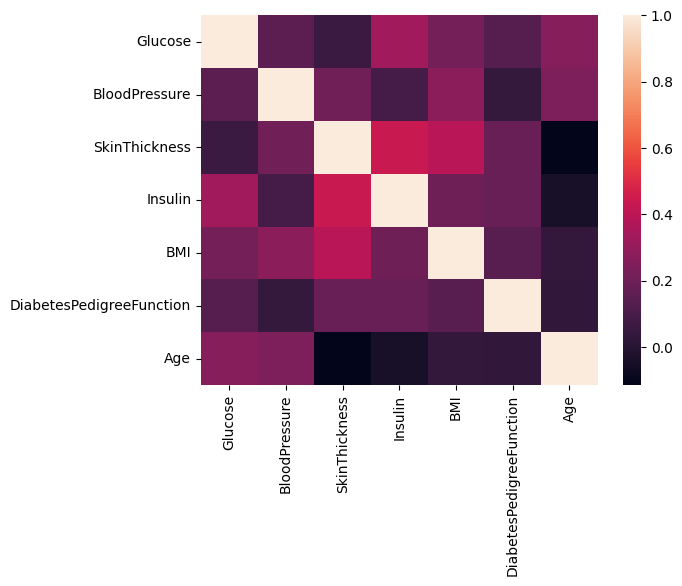

In [ ]:
# 데이터 상관관계 확인 (이 데이터와 저 데이터의 상관관계 근데 사실 상관이 없다. 현재 regression에는)
import seaborn as sns
import matplotlib.pyplot as plt

reg_df = df # move df to classfication df
reg_df = reg_df.drop('Outcome', axis=1)

corr = reg_df.corr()

#sns.heatmap(corr, annot=True, fmt='.0f', cmap='coolwarm')
sns.heatmap(corr)
plt.show()

In [19]:
y = reg_df['Age']             # target
y.head() 

Pregnancies
6    50
1    31
8    32
1    21
0    33
Name: Age, dtype: int64

In [20]:
X = clf_df.drop('Age', axis=1) # fitting data
X.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Outcome
Pregnancies,,,,,,,
6,148,72,35,0,33.6,0.627,1
1,85,66,29,0,26.6,0.351,0
8,183,64,0,0,23.3,0.672,1
1,89,66,23,94,28.1,0.167,0
0,137,40,35,168,43.1,2.288,1


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.25,random_state=0)

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

lg_model = LinearRegression()
lg_model.fit(X_train,y_train)
lg_y = lg_model.predict(X_test)

De_model = DecisionTreeRegressor()
De_model.fit(X_train,y_train)
De_y = lg_model.predict(X_test)

Rd_model = RandomForestRegressor()
Rd_model.fit(X_train,y_train)
Rd_y = lg_model.predict(X_test)

In [23]:
from sklearn.metrics import mean_squared_error # 평균제곱오차

print('---- LinearRegression ----')
print(mean_squared_error(y_test,lg_y))
print('---- DecisionTreeRegressor ----')
print(mean_squared_error(y_test,De_y))
print('---- RandomForestRegressor ----')
print(mean_squared_error(y_test,Rd_y))

---- LinearRegression ----
122.18756269316994
---- DecisionTreeRegressor ----
122.18756269316994
---- RandomForestRegressor ----
122.18756269316994


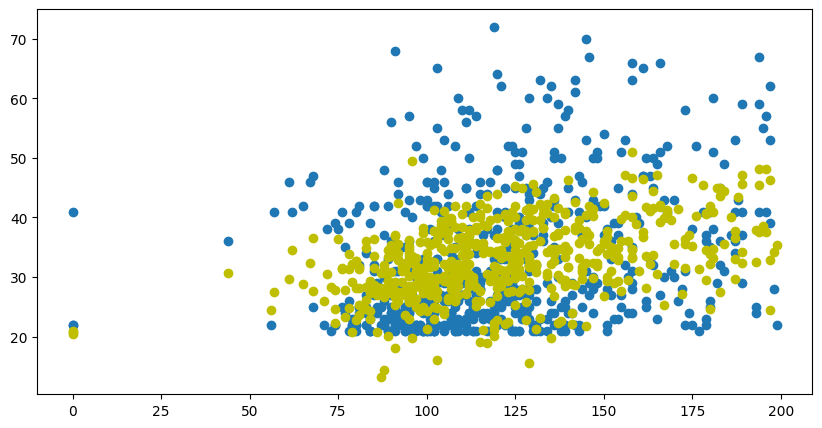

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.scatter(X_test['Glucose'], y_test, label='y_test')
plt.scatter(X_test['Glucose'], lg_y, c='y', label='ly_preds')
#plt.plot(X_train, lr.predict(X_train), color='blue')
plt.show() 